# TP1: Digital Image Processing Fundamentals

Image I/O, format conversion, channel decomposition, histogram, and color spaces using PIL/Pillow.

In [1]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.colors import rgb_to_hsv

%matplotlib inline


## 1. Load and display a color PNG image

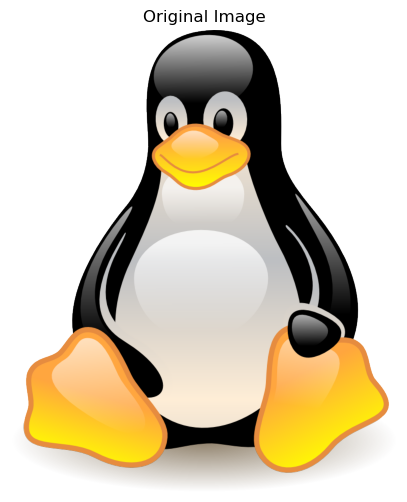

In [2]:
image = Image.open("image.png")
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()


## 2. Image dimensions

In [3]:
width, height = image.size
print(f"Width: {width}px, Height: {height}px")


Width: 764px, Height: 910px


## 3. Save as JPEG and TIFF, compare file sizes

In [4]:
rgb_image = image.convert("RGB")
rgb_image.save("image_converted.jpg", "JPEG")
rgb_image.save("image_converted.tiff", "TIFF")

for fmt, path in [("PNG", "image.png"), ("JPEG", "image_converted.jpg"), ("TIFF", "image_converted.tiff")]:
    print(f"{fmt:4s}: {os.path.getsize(path) / 1024:.2f} KB")


PNG : 117.72 KB
JPEG: 48.55 KB
TIFF: 2036.97 KB


## 4. RGB channel decomposition

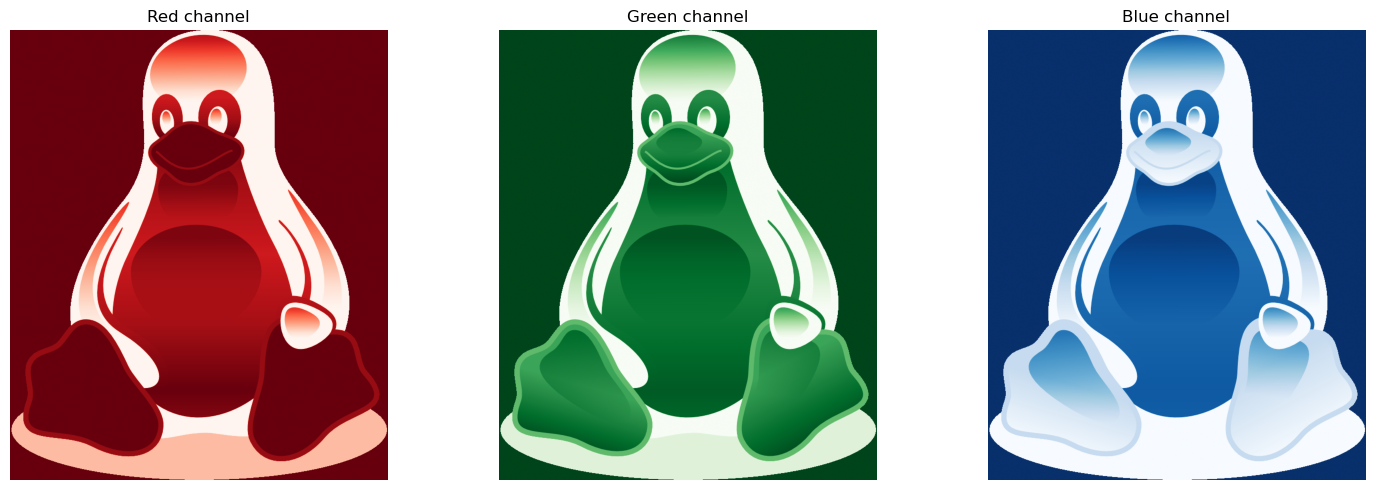

In [5]:
image_array = np.array(image.convert("RGB"))
r, g, b = image_array[:, :, 0], image_array[:, :, 1], image_array[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(r, cmap="Reds");   axes[0].set_title("Red channel");   axes[0].axis("off")
axes[1].imshow(g, cmap="Greens"); axes[1].set_title("Green channel"); axes[1].axis("off")
axes[2].imshow(b, cmap="Blues");  axes[2].set_title("Blue channel");  axes[2].axis("off")
plt.tight_layout()
plt.show()


## 5. Reconstruct image from channels

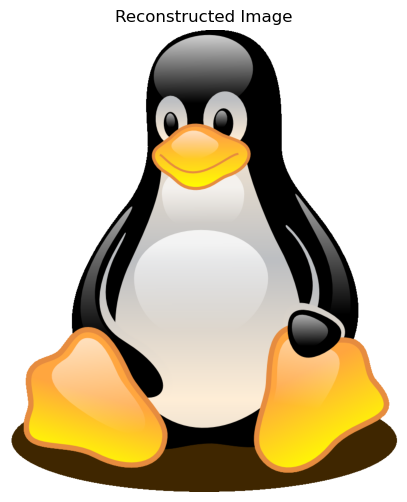

In [6]:
reconstructed = np.dstack((r, g, b))
plt.figure(figsize=(6, 6))
plt.imshow(reconstructed)
plt.title("Reconstructed Image")
plt.axis("off")
plt.show()


## 6. Grayscale conversion

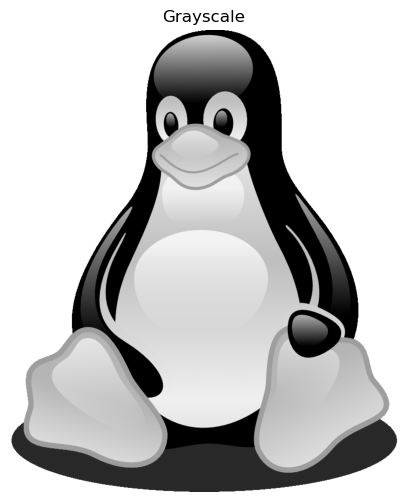

In [7]:
image_gray = image.convert("L")
plt.figure(figsize=(6, 6))
plt.imshow(image_gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()


## 7. Binary (1-bit) conversion

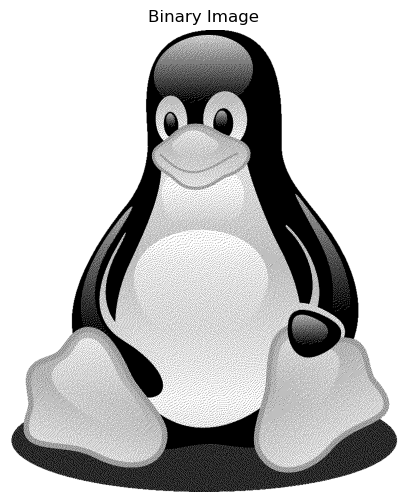

In [8]:
image_binary = image.convert("1")
plt.figure(figsize=(6, 6))
plt.imshow(image_binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()


## 8. Pixel intensity histogram

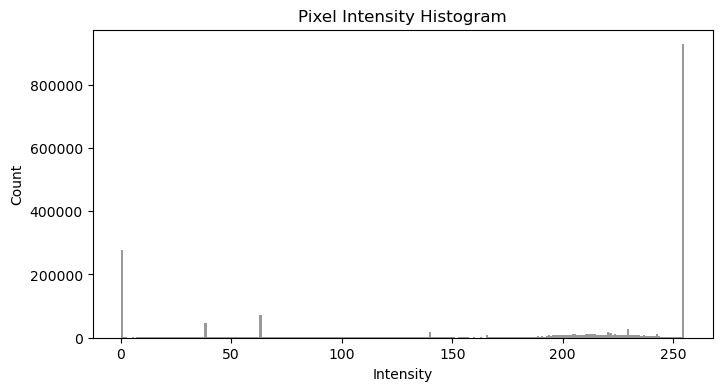

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(image_array.ravel(), bins=256, color="gray", alpha=0.8)
plt.title("Pixel Intensity Histogram")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.show()


## 9. Image inversion

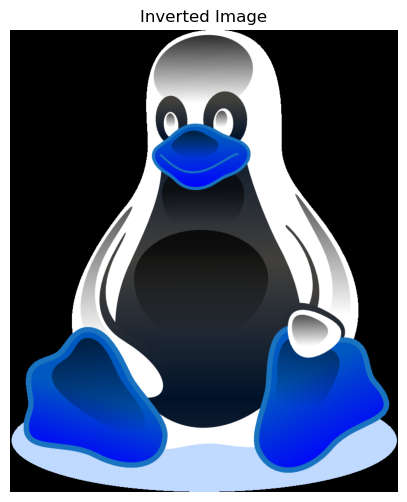

In [10]:
image_inverted = ImageOps.invert(image.convert("RGB"))
plt.figure(figsize=(6, 6))
plt.imshow(image_inverted)
plt.title("Inverted Image")
plt.axis("off")
plt.show()


## 10. HSV color space decomposition

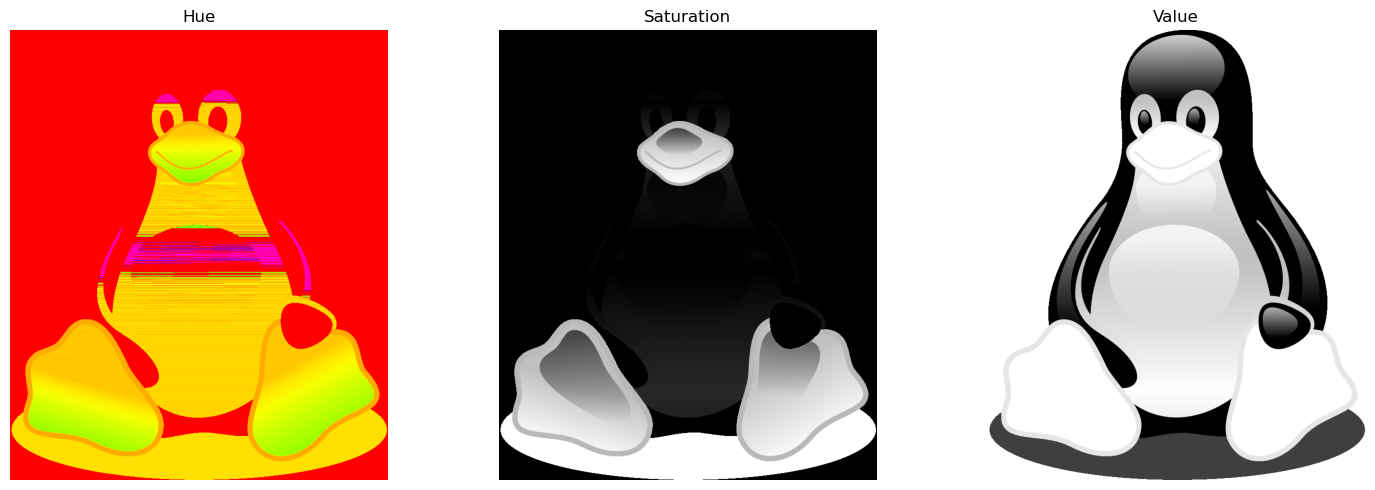

In [11]:
image_float = np.array(image.convert("RGB")) / 255.0
hsv = rgb_to_hsv(image_float)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(hsv[:, :, 0], cmap="hsv");  axes[0].set_title("Hue");        axes[0].axis("off")
axes[1].imshow(hsv[:, :, 1], cmap="gray"); axes[1].set_title("Saturation"); axes[1].axis("off")
axes[2].imshow(hsv[:, :, 2], cmap="gray"); axes[2].set_title("Value");      axes[2].axis("off")
plt.tight_layout()
plt.show()
